# Fairness-Oriented Timetabling

Este notebook prueba la optimización de horarios considerando métricas de equidad.

- **Índice de Jain**: Mide la equitatividad de la distribución de ingresos
- **Coeficiente de Gini**: Mide la desigualdad (0 = igualdad perfecta)
- **Índice de Atkinson**: Pondera más las transferencias de ricos a pobres

## 0. Load Libraries

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from robin.supply.generator.entities import SupplyGenerator
from robin.supply.entities import Supply

from craft import RevenueSimulator
from craft import MealpyTimetabling
from craft import FairnessMetrics

## 1. Generate Supply

In [2]:
supply_config_path = Path("../configs/supply_generator/supply_data.yaml")
generator_config_path = Path("../configs/supply_generator/config.yaml")
generator_save_path = Path('../data/results/supply_fairness.yaml')

Path('../data/results').mkdir(parents=True, exist_ok=True)

generator = SupplyGenerator.from_yaml(
    path_config_supply=supply_config_path,
    path_config_generator=generator_config_path
)

generator.generate(
    n_services=25,
    output_path=generator_save_path,
    seed=42,
    progress_bar=True,
    without_conflicts=False
)

print(f'Generated {len(generator.services)} services')

Generating services all: 100%|██████████| 25/25 [00:00<00:00, 465.28service/s]

Generated 25 services


## 2. Load Supply and Generate Revenue Behavior

In [3]:
supply = Supply.from_yaml(path=str(generator_save_path))
print(f'Loaded {len(supply.services)} services')

revenue_simulator = RevenueSimulator(supply=supply)
revenue_behavior = revenue_simulator.simulate_revenue(alpha=2/3)

print(f'Revenue behavior computed for {len(revenue_behavior)} services')

Loaded 25 services
Revenue behavior computed for 25 services


## 3. Initialize Timetabling Problem

In [4]:
timetabling = MealpyTimetabling(
    requested_services=supply.services,
    revenue_behavior=revenue_behavior,
    safe_headway=10,
    max_stop_time=10
)

print(f'Problem initialized with {timetabling.n_services} services')

Problem initialized with 25 services


## 4. Calcular métricas de equidad

In [5]:
fairness = FairnessMetrics()

service_revenues = timetabling.revenue_calculator.service_revenues
revenue_values = [r['revenue'] for r in service_revenues.values()]

jain = fairness.jain_index(revenue_values)
gini = fairness.gini_coefficient(revenue_values)
atkinson = fairness.atkinson_index(revenue_values)

print("=== Métricas de Equidad ===")
print(f"Índice de Jain:     {jain:.4f} (más cerca de 1 = más equitativo)")
print(f"Coeficiente de Gini: {gini:.4f} (0 = igualdad perfecta)")
print(f"Índice de Atkinson:  {atkinson:.4f} (0 = igualdad perfecta)")

=== Métricas de Equidad ===
Índice de Jain:     0.8804 (más cerca de 1 = más equitativo)
Coeficiente de Gini: 0.1500 (0 = igualdad perfecta)
Índice de Atkinson:  0.0000 (0 = igualdad perfecta)


## 5. Optimización multi-objetivo

Optimizamos considerando tanto ingresos como equidad.

In [6]:
from mealpy import FloatVar
from mealpy.swarm_based import PSO

bounds = []
for lb, ub in timetabling.boundaries.real:
    bounds.append(FloatVar(lb=lb, ub=ub))

class FairnessObjective:
    def __init__(self, timetabling, fairness_calc, alpha=0.7, beta=0.3):
        self.timetabling = timetabling
        self.fairness_calc = fairness_calc
        self.alpha = alpha
        self.beta = beta

    def objective(self, solution):
        try:
            fitness = self.timetabling.objective_function(solution)
            revenue_values = [r['revenue'] for r in self.timetabling.revenue_calculator.service_revenues.values()]
            jain = self.fairness_calc.jain_index(revenue_values)
            return (self.alpha * fitness / 1e6 + self.beta * jain)
        except Exception as e:
            return 1e10

obj_func = FairnessObjective(timetabling, fairness)

problem = {
    'obj_func': obj_func.objective,
    'bounds': bounds,
    'minmax': 'max',
    'verbose': True
}

model = PSO.OriginalPSO(pop_size=10, n_iter=25, w=0.7, c1=1.5, c2=1.5, seed=42)

print("Starting PSO optimization with fairness...")
model.solve(problem)

print(f'Best fitness: {model.g_best.target.fitness}')

2026/04/11 01:06:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=10000, pop_size=10, c1=1.5, c2=1.5, w=0.7)
2026/04/11 01:06:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: 0.27589767622621286, Global best: 0.27589767622621286, Runtime: 0.00657 seconds
2026/04/11 01:06:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: 0.2785158426634178, Global best: 0.2785158426634178, Runtime: 0.00665 seconds
2026/04/11 01:06:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: 0.2785158426634178, Global best: 0.2785158426634178, Runtime: 0.00678 seconds
2026/04/11 01:06:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: 0.2785158426634178, Global best: 0.2785158426634178, Runtime: 0.00643 seconds
2026/04/11 01:06:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: 0.2785158426634178, Global best: 0

Starting PSO optimization with fairness...


2026/04/11 01:06:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 10, Current best: 0.27854072449914297, Global best: 0.27854072449914297, Runtime: 0.00643 seconds
2026/04/11 01:06:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 11, Current best: 0.27854072449914297, Global best: 0.27854072449914297, Runtime: 0.00663 seconds
2026/04/11 01:06:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 12, Current best: 0.27854072449914297, Global best: 0.27854072449914297, Runtime: 0.00661 seconds
2026/04/11 01:06:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 13, Current best: 0.278912299786736, Global best: 0.278912299786736, Runtime: 0.00686 seconds
2026/04/11 01:06:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 14, Current best: 0.278912299786736, Global best: 0.278912299786736, Runtime: 0.00654 seconds
2026/04/11 01:06:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: 

Best fitness: 0.28119715397333617


## 6. Comparar resultados

In [9]:
best_position = model.g_best.solution
schedule = timetabling.get_heuristic_schedule()

from craft import Solution
solution = Solution(real=best_position, discrete=schedule)
updated_services = timetabling.update_supply(str(generator_save_path), solution)

service_revenues_optimized = timetabling.revenue_calculator.service_revenues
revenue_values_optimized = [r['revenue'] for r in service_revenues_optimized.values()]

fairness_initial = fairness.jain_index(revenue_values)
fairness_optimized = fairness.jain_index(revenue_values_optimized)

print("=== Comparación ===")
print(f"Índice Jain inicial:   {fairness_initial:.4f}")
print(f"Índice Jain optimizado: {fairness_optimized:.4f}")

=== Comparación ===
Índice Jain inicial:   0.8804
Índice Jain optimizado: 0.9148


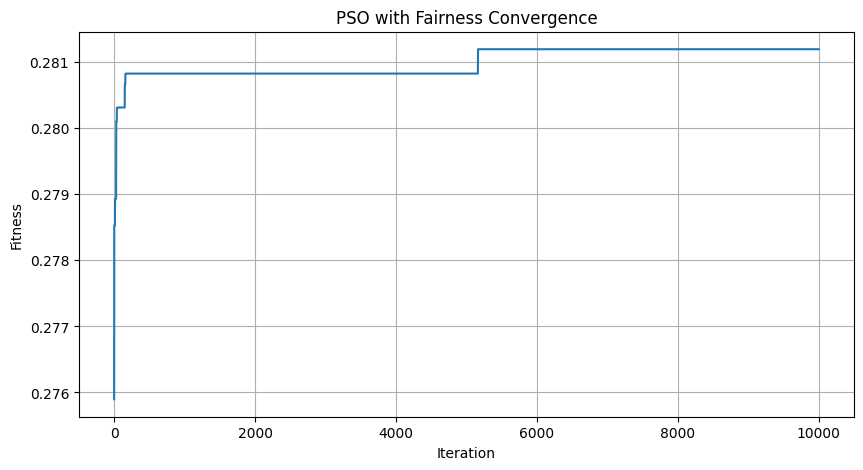

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot([data.target.fitness for data in model.history.list_global_best])
plt.xlabel('Iteration')
plt.ylabel('Fitness')
plt.title('PSO with Fairness Convergence')
plt.grid(True)
plt.show()